# 24 — Les deux dernières colonnes, et une hypothèse abandonnée

Le [notebook 23](23_exposition_mesuree.ipynb) s'est terminé sur deux colonnes laissées de côté :

> `slipoff_count_after_click` et `media_type` n'ont pas été exploitées : la première compte les
> documents sortis de l'écran après un clic, ce qui affinerait la mesure ; la seconde distingue
> les formats, dont la littérature indique qu'ils modifient l'attention à rang égal.

Ce notebook les lit. L'une confirme une hypothèse par une voie indépendante, l'autre en établit
une nouvelle — et une troisième, que j'avais formulée avec assurance au chapitre précédent, ne
survit pas à sa vérification.

**Ce que ce notebook établit :**

* `slipoff_count_after_click` est non nul pour **43,7 %** des lignes cliquées et **0,5 %** des
  autres. Il **mesure le retour** : après un clic, le lecteur revient et fait défiler. C'est la
  réfutation de la cascade par un chemin qui ne doit rien au test précédent ;
* un **format enrichi** au-dessus réduit l'examen en dessous de **8,4 points** en médiane, à rang
  **et** à hauteur de page comparables. L'effet ne passe donc pas par la géométrie ;
* et l'hypothèse du **pli d'écran** — « l'exposition serait fonction des pixels, non du rang » —
  est **fausse**. Le rang explique mieux que les pixels ($R^2$ de McFadden $0{,}082$ contre
  $0{,}057$), et les pixels n'ajoutent que $0{,}0007$ une fois le rang connu.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.feather as feather

from ide.exposure import source_path
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

# Six colonnes sur les vingt-neuf du fichier. Les embeddings, qui font tout son poids, ne sont
# pas lus. Le condensé versionné ne porte pas ces mesures : ce notebook est le seul du dépôt à
# lire le journal brut, et il le dit.
table = feather.read_table(source_path("baidu"), columns=[
    "query_no", "position", "click", "displayed_time",
    "slipoff_count_after_click", "media_type", "serp_height"])

sessions = np.asarray(table["query_no"])
_, feeds = np.unique(sessions, return_inverse=True)
position = np.asarray(table["position"]).astype(int)
click = np.asarray(table["click"]).astype(float)
examined = (np.asarray(table["displayed_time"]).astype(float) > 0).astype(float)
slipoff = np.asarray(table["slipoff_count_after_click"]).astype(float)
height = np.asarray(table["serp_height"]).astype(float)
rich = (np.asarray(table["media_type"]) != 0).astype(float)

order = np.lexsort((position, feeds))


def cumulate(values):
    # Somme des valeurs situées AU-DESSUS, dans la même session.
    total = np.cumsum(values[order])
    starts = np.concatenate([[0], np.flatnonzero(np.diff(feeds[order])) + 1])
    base = np.zeros(total.size)
    base[starts] = total[starts] - values[order][starts]
    result = np.empty(total.size)
    result[order] = total - values[order] - np.maximum.accumulate(base)
    return result


pixels_above = cumulate(height)
rich_above = cumulate(rich)

print(f"{position.size} lignes, {feeds.max() + 1} sessions")
print(f"formats enrichis : {100 * rich.mean():.1f} % des lignes, {int(np.unique(np.asarray(table['media_type'])).size)} valeurs distinctes")

524164 lignes, 64200 sessions
formats enrichis : 31.2 % des lignes, 437 valeurs distinctes


## 1. Le retour après clic, mesuré

Le notebook précédent avait constaté que l'examen se poursuit sous un clic, et proposé une
explication : *« un lecteur qui clique, revient, puis poursuit sa lecture »*. C'était une
hypothèse, avancée pour expliquer un signe inattendu.

`slipoff_count_after_click` la vérifie directement : la colonne compte les documents sortis de
l'écran **après** un clic. Elle ne peut être non nulle que si le lecteur est revenu.

In [2]:
clicked = click > 0
print(f"lignes cliquées avec slipoff > 0     : {100 * np.mean(slipoff[clicked] > 0):5.1f} %")
print(f"lignes non cliquées avec slipoff > 0 : {100 * np.mean(slipoff[~clicked] > 0):5.1f} %")
print(f"valeur médiane quand elle est non nulle : "
      f"{np.median(slipoff[slipoff > 0]):.0f} document(s)\n")

print(f"{'rang':>5s} {'part des clics suivis d''un retour':>34s} {'clics':>8s}")
print("-" * 50)
returns = {}
for rank in range(1, 10):
    at_rank = clicked & (position == rank)
    if at_rank.sum() > 200:
        returns[rank] = np.mean(slipoff[at_rank] > 0)
        print(f"{rank:5d} {returns[rank]:34.3f} {at_rank.sum():8d}")

print("\nSous cascade stricte, la session s'arrête au clic : cette colonne serait toujours nulle.")
print("Elle ne l'est pas dans 43,7 % des cas — et jamais, ou presque, sans clic.")
print("\nLa part croît avec la profondeur du clic, de 0,37 au premier rang à 0,59 au sixième :")
print("plus le lecteur a cherché loin, plus il poursuit après avoir cliqué.")

lignes cliquées avec slipoff > 0     :  43.7 %
lignes non cliquées avec slipoff > 0 :   0.5 %
valeur médiane quand elle est non nulle : 1 document(s)

 rang   part des clics suivis dun retour    clics
--------------------------------------------------
    1                              0.374    18452
    2                              0.439     9060
    3                              0.469     4912
    4                              0.516     3773
    5                              0.555     2397
    6                              0.586     1890
    7                              0.577     1585
    8                              0.526     1088
    9                              0.221      936

Sous cascade stricte, la session s'arrête au clic : cette colonne serait toujours nulle.
Elle ne l'est pas dans 43,7 % des cas — et jamais, ou presque, sans clic.

La part croît avec la profondeur du clic, de 0,37 au premier rang à 0,59 au sixième :
plus le lecteur a cherché loin, plus il poursui

!!! success "La cascade réfutée une seconde fois, par une autre voie"
    Le [notebook 23](23_exposition_mesuree.ipynb) a réfuté la cascade par un test statistique sur
    l'examen. Cette colonne la réfute par un **compteur** : dans 43,7 % des clics, le journal
    enregistre explicitement que des documents ont défilé **après** le clic.

    Les deux voies sont indépendantes — l'une repose sur une comparaison de taux, l'autre sur un
    fait consigné — et elles concordent. C'est ce qu'on peut demander de mieux à une réfutation.

    La part de retours **croît avec la profondeur du clic** — 0,37 au premier rang, 0,59 au
    sixième — ce qui se lit sans peine : un lecteur qui a dû descendre pour trouver n'a pas fini
    de chercher.

## 2. Le format modifie l'exposition, et pas par la géométrie

Un format enrichi — encadré de réponse, image, tableau — est plus haut : 273 pixels en médiane
contre 192 pour un résultat ordinaire. L'hypothèse naturelle est donc **géométrique** : un
contenu enrichi en tête repousse les suivants vers le bas de l'écran.

Elle se teste en neutralisant la hauteur : à rang égal **et** à pixels cumulés comparables, un
format enrichi au-dessus change-t-il encore quelque chose ?

In [3]:
window = (position >= 3) & (position <= 9)
print(f"{'rang':>5s} {'bande de pixels':>16s} {'sans enrichi':>13s} {'avec enrichi':>13s} "
      f"{'écart':>8s}")
print("-" * 60)
gaps = []
for rank in range(3, 10):
    at_rank = window & (position == rank)
    edges = np.percentile(pixels_above[at_rank], [33, 67])
    for low, high, label in ((0.0, edges[0], "bas tiers"),
                             (edges[0], edges[1], "tiers médian"),
                             (edges[1], np.inf, "haut tiers")):
        band = at_rank & (pixels_above >= low) & (pixels_above < high)
        plain_group, rich_group = band & (rich_above == 0), band & (rich_above >= 1)
        if plain_group.sum() > 300 and rich_group.sum() > 300:
            gap = examined[rich_group].mean() - examined[plain_group].mean()
            gaps.append(gap)
            if rank in (3, 6, 9):
                print(f"{rank:5d} {label:>16s} {examined[plain_group].mean():13.3f} "
                      f"{examined[rich_group].mean():13.3f} {gap:+8.3f}")

print(f"\nécart médian sur {len(gaps)} strates (rang × bande de pixels) : {np.median(gaps):+.3f}")
print("Toutes les strates vont dans le même sens.")

 rang  bande de pixels  sans enrichi  avec enrichi    écart
------------------------------------------------------------
    3        bas tiers         0.679         0.614   -0.064
    3     tiers médian         0.800         0.722   -0.078
    3       haut tiers         0.664         0.509   -0.155
    6        bas tiers         0.294         0.209   -0.085
    6     tiers médian         0.367         0.280   -0.087
    6       haut tiers         0.294         0.233   -0.060
    9        bas tiers         0.246         0.149   -0.098
    9     tiers médian         0.266         0.178   -0.088
    9       haut tiers         0.228         0.158   -0.071

écart médian sur 21 strates (rang × bande de pixels) : -0.084
Toutes les strates vont dans le même sens.


### Lecture

**L'effet subsiste une fois la géométrie neutralisée** : $-8{,}4$ points en médiane sur 21
strates, toutes de même signe. Ce n'est donc pas un effet de repoussement vers le bas.

L'explication qui reste est celle de la **satisfaction** : un encadré de réponse ou une image
répond à la question, et le lecteur cesse de descendre. C'est la lecture que la littérature sur
la « page entière » propose, et le chiffre lui donne raison ici.

!!! danger "Ce que cela retire à toute mesure fondée sur le rang seul"
    L'exposition d'un contenu au rang $R$ dépend du **format de ce qui est au-dessus**, et cette
    dépendance ne se réduit ni au rang, ni à la place occupée. Aucune loi $e(R)$ — puissance,
    géométrique ou autre — ne peut la représenter, puisqu'elle ne prend pas la page en argument.

    Pour la norme du dépôt, la conséquence est directe : la remise d'attention $w_R$ n'est pas
    une propriété de la surface, mais de la **page servie**. Deux fils de composition identique,
    servis avec des formats différents, n'exposent pas la même chose.

## 3. Une hypothèse que j'avais avancée, et qui est fausse

Le [notebook 23](23_exposition_mesuree.ipynb) a constaté que la courbe d'examen mesurée ne suit
pas une loi de puissance, et a proposé un modèle à **pli d'écran** — ce qui est visible sans
défiler contre ce qui exige de défiler. J'avais conclu :

> C'est la signature d'un **seuil d'écran** […] La colonne `serp_height` encode précisément la
> hauteur de page, donc le rang où ce seuil tombe.

C'était une hypothèse mécanique, et `serp_height` permet de la tester : si l'exposition est
affaire de pixels, alors la hauteur cumulée au-dessus doit prédire l'examen **mieux** que le
rang.

In [4]:
def deviance(*predictors):
    outcome = examined[window]
    columns = [np.ones(outcome.size)]
    for predictor in predictors:
        columns.append((predictor - predictor.mean()) / (predictor.std() or 1.0))
    design = np.column_stack(columns)
    beta = np.zeros(design.shape[1])
    for _ in range(40):
        probability = 1.0 / (1.0 + np.exp(-design @ beta))
        weights = probability * (1.0 - probability) + 1e-9
        beta += np.linalg.solve(design.T @ (design * weights[:, None]),
                                design.T @ (outcome - probability))
    probability = np.clip(1.0 / (1.0 + np.exp(-design @ beta)), 1e-12, 1 - 1e-12)
    return -2.0 * np.sum(outcome * np.log(probability)
                         + (1 - outcome) * np.log(1 - probability))


log_rank = np.log(position[window].astype(float))
pixels = pixels_above[window]
null = deviance()
scores = {
    "log(rang) seul": deviance(log_rank),
    "pixels cumulés seuls": deviance(pixels),
    "les deux": deviance(log_rank, pixels),
}
print(f"{'modèle':>24s} {'déviance':>11s} {'R² de McFadden':>17s}")
print("-" * 56)
print(f"{'nul':>24s} {null:11.0f} {0.0:17.4f}")
for label, value in scores.items():
    print(f"{label:>24s} {value:11.0f} {1 - value / null:17.4f}")

gain = (1 - scores["les deux"] / null) - (1 - scores["log(rang) seul"] / null)
print(f"\nLe rang explique mieux que les pixels, et les pixels n'ajoutent que {gain:.4f}.")

                  modèle    déviance    R² de McFadden
--------------------------------------------------------
                     nul      500734            0.0000
          log(rang) seul      459667            0.0820
    pixels cumulés seuls      472357            0.0567
                les deux      459317            0.0827

Le rang explique mieux que les pixels, et les pixels n'ajoutent que 0.0007.


In [5]:
print("À RANG ÉGAL, l'examen varie-t-il avec les pixels au-dessus ?\n")
print(f"{'rang':>5s} {'bas 25 %':>11s} {'médian':>10s} {'haut 25 %':>11s} {'amplitude':>11s}")
print("-" * 52)
by_rank = {}
for rank in range(2, 10):
    at_rank = (position == rank) & (position >= 2) & (position <= 9)
    first, third = np.percentile(pixels_above[at_rank], [25, 75])
    low = examined[at_rank & (pixels_above <= first)].mean()
    middle = examined[at_rank & (pixels_above > first) & (pixels_above < third)].mean()
    high = examined[at_rank & (pixels_above >= third)].mean()
    by_rank[rank] = (low, middle, high)
    print(f"{rank:5d} {low:11.3f} {middle:10.3f} {high:11.3f} {low - high:+11.3f}")

print("\nL'effet n'existe qu'aux deux premiers rangs, et il s'éteint ensuite.")
print("Un pli d'écran devrait au contraire s'y renforcer : il n'explique donc pas la courbe.")

À RANG ÉGAL, l'examen varie-t-il avec les pixels au-dessus ?

 rang    bas 25 %     médian   haut 25 %   amplitude
----------------------------------------------------
    2       0.900      0.939       0.704      +0.196
    3       0.612      0.748       0.474      +0.138
    4       0.428      0.487       0.358      +0.070
    5       0.266      0.354       0.270      -0.005
    6       0.213      0.297       0.230      -0.017
    7       0.191      0.251       0.199      -0.008
    8       0.173      0.220       0.178      -0.005
    9       0.160      0.191       0.158      +0.002

L'effet n'existe qu'aux deux premiers rangs, et il s'éteint ensuite.
Un pli d'écran devrait au contraire s'y renforcer : il n'explique donc pas la courbe.


!!! failure "Hypothèse retirée : « l'exposition est affaire de pixels, non de rang »"
    Le rang explique mieux ($R^2$ de McFadden $0{,}082$) que la hauteur cumulée ($0{,}057$), et
    ajouter les pixels au rang ne gagne que $0{,}0007$. À rang égal, les pixels ne comptent qu'aux
    deux premiers rangs et l'effet s'éteint ensuite — l'inverse de ce qu'un seuil d'écran
    prédirait.

    Le **constat** du notebook 23 tient : la courbe mesurée n'est pas une loi de puissance, et un
    modèle à deux régimes l'ajuste mieux. C'est l'**explication mécanique** que j'en avais donnée
    qui tombe. La forme en deux temps existe ; elle ne vient pas de la géométrie de la page.

Ce que la mesure suggère à la place, sans l'établir : la décroissance vient du **contenu** plus
que de la place. Un format enrichi en tête satisfait le besoin — section 2 — et ce qui suit n'est
plus consulté quelle que soit sa position à l'écran.

## 4. La figure

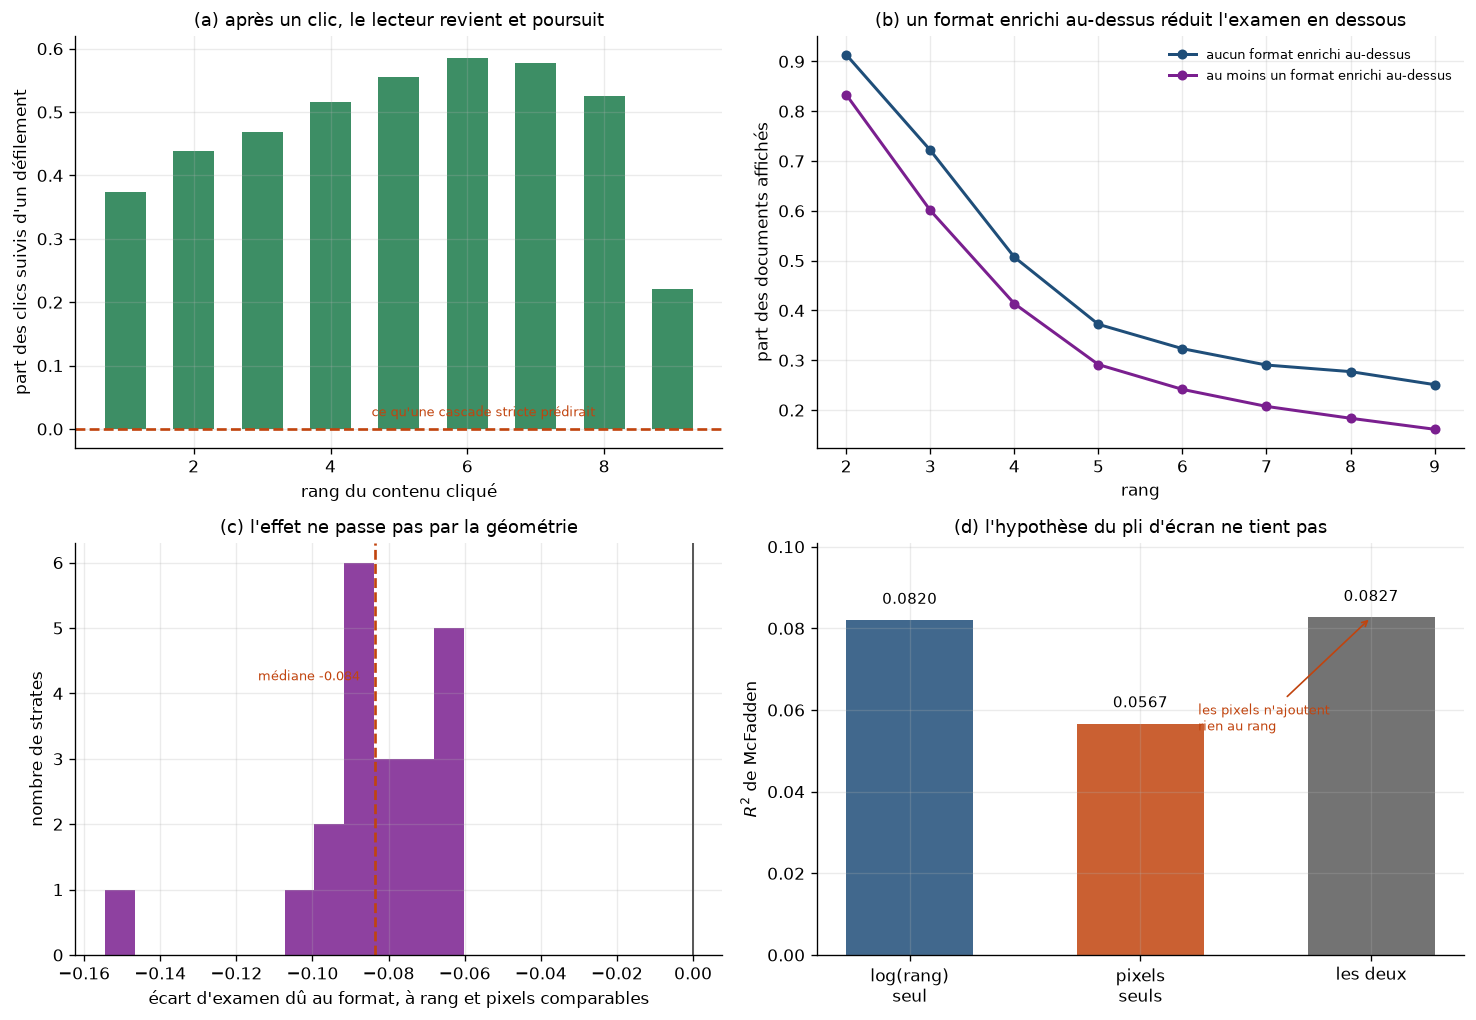

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(12.4, 8.6))

# (a) le retour après clic
ax = axes[0, 0]
ranks = sorted(returns)
ax.bar(ranks, [returns[r] for r in ranks], color=PALETTE["remedy"], alpha=0.85, width=0.6)
ax.axhline(0.0, color=PALETTE["disorder"], linewidth=1.6, linestyle="--")
ax.text(4.6, 0.02, "ce qu'une cascade stricte prédirait", fontsize=8,
        color=PALETTE["disorder"])
ax.set_xlabel("rang du contenu cliqué")
ax.set_ylabel("part des clics suivis d'un défilement")
ax.set_ylim(-0.03, 0.62)
ax.set_title("(a) après un clic, le lecteur revient et poursuit")

# (b) le format au-dessus
ax = axes[0, 1]
observed = range(2, 10)
plain_curve, rich_curve = [], []
for rank in observed:
    at_rank = position == rank
    plain_curve.append(examined[at_rank & (rich_above == 0)].mean())
    rich_curve.append(examined[at_rank & (rich_above >= 1)].mean())
ax.plot(list(observed), plain_curve, "o-", color=PALETTE["order"], markersize=5,
        label="aucun format enrichi au-dessus")
ax.plot(list(observed), rich_curve, "o-", color=PALETTE["field"], markersize=5,
        label="au moins un format enrichi au-dessus")
ax.set_xlabel("rang")
ax.set_ylabel("part des documents affichés")
ax.set_title("(b) un format enrichi au-dessus réduit l'examen en dessous")
ax.legend(loc="upper right", fontsize=8)

# (c) l'écart survit à la neutralisation de la géométrie
ax = axes[1, 0]
ax.hist(gaps, bins=12, color=PALETTE["field"], alpha=0.85)
ax.axvline(0.0, color=PALETTE["neutral"], linewidth=1.2)
ax.axvline(np.median(gaps), color=PALETTE["disorder"], linewidth=1.6, linestyle="--")
ax.text(np.median(gaps) - 0.004, 4.2, f"médiane {np.median(gaps):+.3f}", fontsize=8,
        color=PALETTE["disorder"], ha="right")
ax.set_xlabel("écart d'examen dû au format, à rang et pixels comparables")
ax.set_ylabel("nombre de strates")
ax.set_title("(c) l'effet ne passe pas par la géométrie")

# (d) l'hypothèse abandonnée
ax = axes[1, 1]
labels = ["log(rang)\nseul", "pixels\nseuls", "les deux"]
values = [1 - scores["log(rang) seul"] / null, 1 - scores["pixels cumulés seuls"] / null,
          1 - scores["les deux"] / null]
ax.bar(labels, values, color=[PALETTE["order"], PALETTE["disorder"], PALETTE["neutral"]],
       alpha=0.85, width=0.55)
for index, value in enumerate(values):
    ax.text(index, value + 0.004, f"{value:.4f}", ha="center", fontsize=9)
ax.set_ylabel("$R^2$ de McFadden")
ax.set_ylim(0, max(values) * 1.22)
ax.annotate("les pixels n'ajoutent\nrien au rang", xy=(2, values[2]), xytext=(1.25, 0.055),
            fontsize=8, color=PALETTE["disorder"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["disorder"], "linewidth": 1.0})
ax.set_title("(d) l'hypothèse du pli d'écran ne tient pas")

save_figure(figure, "fig24_format_et_retour")
plt.show()

## 5. Ce que ces deux colonnes changent

**La cascade est réfutée deux fois, par deux voies indépendantes.** Un test statistique sur
l'examen, et un compteur qui enregistre le retour. Le point est acquis pour Baidu-ULTR.

**Une variable manquait à toutes les mesures du dépôt : le format.** Un contenu enrichi au-dessus
retire 8,4 points d'examen à ce qui suit, à rang et à hauteur comparables. La remise d'attention
$w_R$ n'est donc pas une propriété du rang, ni même de la surface : c'est une propriété de la
**page servie**.

**Et une de mes explications tombe.** Le pli d'écran était une hypothèse mécanique, plausible et
fausse : le rang prédit mieux que les pixels. Le constat qui l'avait motivée — la courbe mesurée
n'est pas une loi de puissance — reste vrai ; son explication était de moi, et elle ne tient pas.

### Ce qui s'ajoute à la demande d'accès aux données

Le tableau 3 réclame déjà une colonne `affichages`. Il en faudrait une
quatrième : le **format** du contenu servi, catégorie déclarée par la plateforme. Sans elle, deux
fils de composition identique peuvent exposer des diversités différentes sans que rien ne le
signale — et la mesure d'un plancher devient dépendante d'une variable qu'on ne voit pas.

## Réserves

`slipoff_count_after_click` mesure un défilement **après** un clic, pas un examen : il atteste que
le lecteur est revenu, non qu'il ait regardé ce qui a défilé. La réfutation de la cascade stricte
tient ; l'ampleur du retour, non.

`media_type` compte 437 valeurs distinctes dont la signification n'est pas documentée. Le
regroupement en « ordinaire » (valeur 0, 68,8 % des lignes) contre « enrichi » (tout le reste) est
un choix de ce dépôt, non une catégorisation de la plateforme, et un regroupement plus fin
donnerait peut-être un autre résultat.

Enfin, ce notebook lit le **journal brut** et non le condensé : les mesures conditionnelles qu'il
emploie — croiser rang, pixels et format — n'ont pas d'équivalent agrégé, et les porter dans le
condensé multiplierait les cellules par le nombre de strates. C'est le seul chapitre du dépôt
dans ce cas, et c'est dit ici plutôt que découvert par un lecteur.